# **1. ViT**
ViT(Vision Transformer)는 이미지를 일정 크기의 패치(예: 16×16)로 나눈 뒤 각 패치를 임베딩 벡터로 투영해 토큰 시퀀스로 만들고, 여기에 위치 임베딩을 더해 트랜스포머 인코더(멀티헤드 자기어텐션+FFN)로 처리하여 분류 등의 다운스트림 작업을 수행하는 모델입니다. 분류의 경우 BERT처럼 맨 앞에 [CLS] 토큰을 두고 그 출력으로 최종 예측을 합니다. CNN이 지역적 합성곱과 계층적 다운샘플링으로 전역 정보를 “깊이”에서 얻게 되는 반면, ViT는 자기어텐션(self attention)으로 처음부터 전역 관계를 직접 학습하는 것이 특징입니다. 충분한 데이터와 적절한 사전학습·증강이 있을 때 스케일이 클수록 성능이 잘 향상되지만, 어텐션의 계산량이 토큰 수 제곱(O(N²))에 비례해 해상도가 높거나 패치가 너무 작으면 비용이 크게 늘 수 있습니다.

![ViT](./images/ViT.png)

> NLP Transformer에서 단어(Token)가 들어가던 자리에 ViT에서는 이미지 patch token이 들어감

### 1. NLP transformer
- 문장을 Token으로 분리
- Token ID > Embedding
- [CLS] Token
- Position Embedding
- Multi-Head Self-Attention
- FFN/MLP
- 문장 분류

### 2. Vision Transformer
- 이미지를 Patch로 분리
- Patch > Linear Projection
- [CLS] Token
- Position Embedding
- Multi-Head Self-Attention
- FFN/MLP
- 이미지 분류

```
예) 이미지 (3, 224, 224)
하나의 patch 16 * 16 (한 패치 크기를 16*16으로 줌)
한 변의 크기: 224 / 16 = 14
패치의 수: 14*14 = 196
[CLS] Token 추가 > 패치 수의 수 197
sequence 길이 = 197
```
- 위 내용으로 NLP의 Self-Attention과 계산 원리는 같음
- 각 patch가 Query, Key, Value를 만들고 다른 모든 patch와의 관계를 계산

In [1]:
import json
import random
import math
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [ ]:
rng = np.random.default_rng(SEED) # 랜덤한 객체를 뽑을 수 있는 객체
image = rng.random((8,8,3), dtype=np.float32) # (8,8,3) : opencv형태 h,w,c

patch_size = 4
h, w, c = image.shape

# 패치 세로 개수, patch_h, 패치 가로 개수, patch_W, c
patches = image.reshape(h // patch_size, patch_size, w // patch_size, patch_size, c)
patches = patches.transpose(0, 2, 1, 3, 4)

patches.shape

# 총 patch 수, patch_h, patch_w, c
patches = patches.reshape(-1, patch_size, patch_size, c) # 총 패치 수 자동로 구해줌

print('원본 이미지: ', image.shape)
print('patches: ', patches.shape)

원본 이미지:  (8, 8, 3)
patches:  (4, 4, 4, 3)


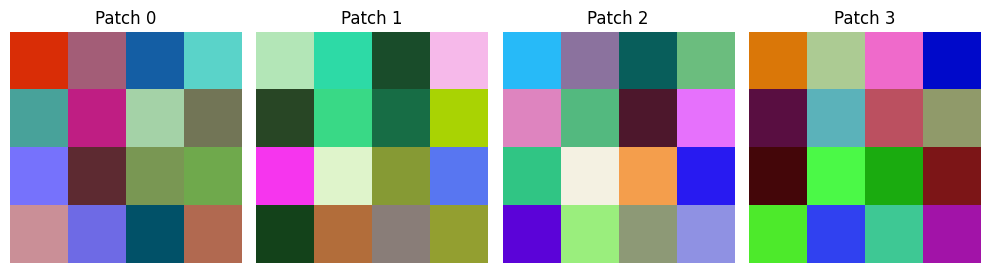

In [9]:
fig, axes = plt.subplots(1, len(patches), figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(patches[i])
    ax.set_title(f"Patch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Conv2d가 Patch Embedding이 되는 이유
- kernel_size=16, stride=16 인 convolution은 서로 겹치지 않는 16*16 영역을 한 번씩 확인
- 출력 channel을 embed_dim으로 설명하면 각 patch를 embed_dim 차원의 vector로 바꾸는 효과가 나게됨 
- Patch 자르기 > Flatten > Linear == Conv2d(kernel=patch_size, stride=patch.size)
```
Linear를 이용
첫 번째 patch > Flatten [1, 2, 5, 6] > Linear(4, 8) > [0.2, 0.5, ...]
[1 2]
[5 6]

Conv2d를 이용
nn.Conv2d(in_channels=1, out_channels=8, kernel_size=2, stride=2)
하나의 패치 kernel1: 0.2, kernel2: 0.5, kernel3: 0.1, ... kernel8: 0.6
```

In [ ]:
class Patchembedding(nn.Module):
    def __init__(self, patch_size=4, in_channels=3, embed_dim=32):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size) # embed_dim 은 몇 개로 내보낼지

    def forward(self, x):
        # x: (B, C, H, W)  예시 input [1, 3, 8, 8]
        x = self.proj(x)
        # x: (B, D, H/P, W/P) [1, 32, 2, 2] [배치크기, 출력 dim, 높이/패치 크기, 너비/패치 크기]
        x = x.flatten(2) # 2번 차원부터 마지막 차원까지 전부 하나로 합치라는 뜻. 예시로는 2와 2를 합침
        # x: (B, D, N) [1, 32, 4]
        x = x.transpose(1, 2)
        # x: (B, N, D) [1, 4, 32]
        return x

In [13]:
sample = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0) # c, h, w
print(sample.shape)
patch_embed = Patchembedding(patch_size=4, in_channels=3, embed_dim=32)
tokens = patch_embed(sample)
print('토큰: ', tokens.shape)

torch.Size([1, 3, 8, 8])
토큰:  torch.Size([1, 4, 32])


### [CLS] Token과 Position Embedding
- Self-Attention 자체에는 순서나 위치 개념이 없음
- patch가 이미지의 어느 위치에서 왔는지 알려주는 Position Embedding이 필요
- [CLS] token은 NLP의 BERT에서 사용하던 방식과 매우 유사
- 모든 patch와 attention을 주고 받으면서 이미지 전체를 대표하는 표현으로 학습되고, 마지막에 이 token을 classification head에 넣어줌

In [ ]:
# B: 이미지 개수
# N: 이미지 한 장을 4개의 Patch로 나눔
# D: 각 Patch를 32개의 숫자로 표현
# Patch Embedding이 끝난 후, [CLS] Token과 Position Embedding을 추가하는 과정
B, N, D = tokens.shape
cls_token = nn.Parameter(torch.zeros(1, 1, D)) # (1, 1, 32) # Parameter 적용시 grad true가 되어 학습이 됨
pos_embed = nn.Parameter(torch.zeros(1, N+1, D)) # N + 1은 patch 개수 + CLS가 하나 붙어서
nn.init.trunc_normal_(cls_token, std=0.02) # 절단 정규 분포. 값이 지정된 범위가 아니면 나올 수 없음. 즉 이상치가 나올 수 없음
nn.init.trunc_normal_(pos_embed, std=0.02)
# cls_token: (1,1,32) > expand(8, -1 ,-1) > (8, 1, 32)
# expand(): Batch 크기에 맞게 [CLS] Token을 확장. -1 기존 크기를 유지
# expand 데이터를 실제로 복사하지 않고, 같은 데이터를 참조하는 확장된 View 만듬
# Patch1 Patch2 Patch3 Patch2 > [CLS] Patch1 Patch2 Patch3 Patch2
x = torch.cat([cls_token.expand(B, -1, -1), tokens], dim=1) # 앞에 CLS 토큰 합치기 위해 # 행으로 합치기
# x: (1, 5, 32), pos_embed: (1,5, 32)
x = x + pos_embed # shpae은 안바뀌고 값만 추가됨
print('Patch token 수: ', N)
print('CLS 추가 후: ',x.shape)

Patch token 수:  4
CLS 추가 후:  torch.Size([1, 5, 32])


### Transformer Encoder에 넣기

```
입력 > LayerNorm > Multi-Head self-Attention > FFN > 출력

D: 차원
nhead: Multi-Head self-Attention, n개 사용 > 서로 다른 관계를 학습할 기회
dim _feedforward: 표현을 더 풍부하게 변환하는 역할
batch_first: (B, N, D)
norm_first: Layer Norm을 Attention과 FFN보다 먼저 할 것인지 설정
```

In [15]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=D, nhead=4, dim_feedforward=D*4, dropout=0.1, activation="gelu", batch_first=True, norm_first=True
)

encoder = nn.TransformerEncoder(encoder_layer, num_layers=2, norm=nn.LayerNorm(D))
z = encoder(x)
classifier = nn.Linear(D, 10)
logits = classifier(z[:, 0])

print("Encoder 출력: ", z.shape)
print('분류 logits: ', logits.shape)
print('예측 class: ', logits.argmax(dim=1).item())

Encoder 출력:  torch.Size([1, 5, 32])
분류 logits:  torch.Size([1, 10])
예측 class:  3


C:\Users\dorot\AppData\Local\Temp\ipykernel_26988\3985180587.py:5: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  encoder = nn.TransformerEncoder(encoder_layer, num_layers=2, norm=nn.LayerNorm(D))


# **2. 번호판 분류하기**

In [16]:
DATA_ROOT = Path("./data/ViT")

ANNOTATION_PATH = DATA_ROOT / "annotations.json"
IMAGE_DIR = DATA_ROOT / "images"
MODEL_DIR = Path("./vit_train_results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT       :", DATA_ROOT.resolve())
print("ANNOTATION_PATH :", ANNOTATION_PATH.resolve())
print("IMAGE_DIR       :", IMAGE_DIR.resolve())

DATA_ROOT       : C:\harwoon\12_NLP\data\ViT
ANNOTATION_PATH : C:\harwoon\12_NLP\data\ViT\annotations.json
IMAGE_DIR       : C:\harwoon\12_NLP\data\ViT\images


In [17]:
with ANNOTATION_PATH.open("r", encoding="utf-8") as f:
    annotations = json.load(f)

print("전체 데이터 개수:", len(annotations))
print("첫 annotation:", annotations[0])

전체 데이터 개수: 36828
첫 annotation: {'filename': '21구2298.jpg', 'labels': '2298'}


```
하나의 이미지에서 4개의 숫자를 각각 예측하는 Multi-Head Classification 문제
예) 정답이 '1234' Head:1, Head2:2, Head:3, Head:4
Transformer backbone은 하나를 공유하고, 마지막 classification head만 4개로 나눔
Transformer 관점에서는 공통 encoder 표현을 여러 task head가 공유하는 multi-task learning과 비슷함
```

In [18]:
from collections import Counter

position_counts = [Counter() for _ in range(4)]

for item in annotations:
    for pos, label in enumerate(item["labels"]):
        position_counts[pos][int(label)] += 1

for pos, counts in enumerate(position_counts, start=1):
    print(f"\n{pos}번째 자리 분포")
    print(dict(sorted(counts.items())))


1번째 자리 분포
{0: 3978, 1: 4091, 2: 3617, 3: 3505, 4: 3611, 5: 4056, 6: 4110, 7: 3340, 8: 3535, 9: 2985}

2번째 자리 분포
{0: 3426, 1: 3876, 2: 3793, 3: 3769, 4: 3644, 5: 3762, 6: 3698, 7: 3683, 8: 3645, 9: 3532}

3번째 자리 분포
{0: 3647, 1: 3663, 2: 3762, 3: 3597, 4: 3550, 5: 3948, 6: 3789, 7: 3631, 8: 3623, 9: 3618}

4번째 자리 분포
{0: 3594, 1: 3755, 2: 3658, 3: 3694, 4: 3440, 5: 3681, 6: 3595, 7: 3866, 8: 3785, 9: 3760}


In [19]:
indices = np.arange(len(annotations))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

split = int(len(indices) * 0.9)
train_idx = indices[:split]
val_idx = indices[split:]

train_annot = [annotations[i] for i in train_idx]
val_annot = [annotations[i] for i in val_idx]

print("Train:", len(train_annot))
print("Val  :", len(val_annot))

Train: 33145
Val  : 3683


In [ ]:
#데이터셋
#데이터로더
#transformer 허깅페이스에서 가져와 씀: vit_small_patch16_224

In [24]:
# Dataset
# 이미지 텐서와 라벨 텐서 반환
# Dataloader는 dataset에 데이터가 몇 개인지, i번째 데이터에 대해 물음

class PlateDataset(Dataset):
    def __init__(self, annotations, image_dir, transform=None):
        self.annotations = annotations     # [{'filename': '21구2298.jpg', 'labels': '2298'}, ...]
        self.image_dir = image_dir         # Path("./data/ViT/images")
        self.transform = transform         # 이미지 변환 방법

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # i번째 item 꺼내기
        item = self.annotations[idx]

        # 이미지 열기
        image_path = self.image_dir / item["filename"] 
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)

        # annotation에 있는 라벨이 문자열이므로 이를 개별 숫자 텐서로 변환
        digits = [int(ch) for ch in item["labels"]]          # [2, 2, 9, 8]
        label = torch.tensor(digits, dtype=torch.long)       # tensor([2, 2, 9, 8])
    
        return image, label

In [25]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                     # 크기 통일 (ViT 입력 크기)
    transforms.ToTensor(),                             # PIL → 텐서, 값 0~255 → 0~1, 모양 (H,W,C) → (C,H,W)
    transforms.Normalize(mean=[0.5, 0.5, 0.5],         # 0~1 → -1~1
                         std=[0.5, 0.5, 0.5]),
])

val_transform = train_transform   # 지금은 증강이 없으니 같은 것을 써도 됨

In [26]:
train_ds = PlateDataset(train_annot, IMAGE_DIR, train_transform)
val_ds = PlateDataset(val_annot, IMAGE_DIR, val_transform)

print(len(train_ds), len(val_ds))     # 33145 3683

img, label = train_ds[0]
print(img.shape, img.dtype)           # torch.Size([3, 224, 224]) torch.float32
print(label, label.dtype)             # tensor([숫자 4개]) torch.int64
print(train_annot[0])                 # 위 label과 숫자가 같은지 눈으로 비교

33145 3683
torch.Size([3, 224, 224]) torch.float32
tensor([7, 5, 6, 5]) torch.int64
{'filename': '85노7565.jpg', 'labels': '7565'}


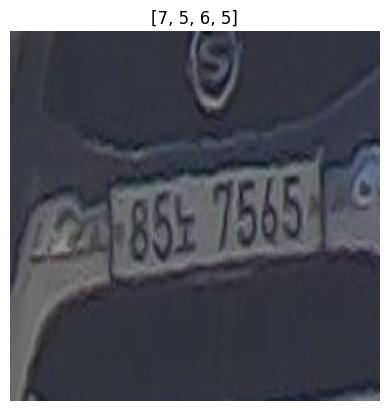

In [27]:
plt.imshow((img.permute(1, 2, 0) * 0.5 + 0.5).numpy())
plt.title(str(label.tolist()))
plt.axis("off")
plt.show()

In [28]:
# 데이터로더

BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,          # train은 섞기
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,          # val은 섞지 않기
    num_workers=0,
)

In [29]:
print(len(train_loader), len(val_loader))   # 1036 116

1036 116


In [30]:
images, labels = next(iter(train_loader))
print(images.shape)   # torch.Size([32, 3, 224, 224])
print(labels.shape)   # torch.Size([32, 4])
print(labels[:3])     # 앞 3장의 정답 숫자

torch.Size([32, 3, 224, 224])
torch.Size([32, 4])
tensor([[1, 5, 6, 8],
        [7, 3, 2, 6],
        [9, 1, 7, 4]])


In [31]:
import timm

class PlateViT(nn.Module):
    def __init__(self, num_digits=4, num_classes=10):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_small_patch16_224", pretrained=True, num_classes=0
        )
        feat_dim = self.backbone.num_features          # 384
        self.heads = nn.ModuleList(
            [nn.Linear(feat_dim, num_classes) for _ in range(num_digits)]
        )

    def forward(self, x):
        feat = self.backbone(x)                        # (B, 384)
        outs = [head(feat) for head in self.heads]     # (B, 10) × 4
        logits = torch.stack(outs, dim=1)            # (B, 4, 10)
        return logits

c:\harwoon\12_NLP\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
model = PlateViT().to(DEVICE)

images, labels = next(iter(train_loader))
with torch.no_grad():                    # 확인만 할 거라 기울기 계산은 끔 (빠르고 메모리 절약)
    logits = model(images.to(DEVICE))

print(logits.shape)                      # torch.Size([32, 4, 10])
print(labels.shape)                      # torch.Size([32, 4])
print(logits.argmax(dim=2)[:3])          # 앞 3장의 예측 숫자 (아직 학습 전이라 엉터리)
print(labels[:3])                        # 실제 정답

c:\harwoon\12_NLP\venv\lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dorot\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\harwoon\12_NLP\venv\lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to effi

torch.Size([32, 4, 10])
torch.Size([32, 4])
tensor([[8, 8, 7, 0],
        [3, 8, 7, 8],
        [8, 6, 0, 2]])
tensor([[2, 6, 7, 5],
        [4, 4, 4, 6],
        [9, 0, 6, 5]])
